Import libraries

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns

Load training and validation datasets

In [2]:
train_df = pd.read_csv("train.csv")
validation_df = pd.read_csv("validation.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

train_df.head()

Train shape: (2700, 2)
Validation shape: (338, 2)


,Question,Answer
0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...
1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...
2,What role do community events or festivals pla...,Community events or festivals provide opportun...
3,How can blood donation centers collaborate wit...,Blood donation centers can partner with transp...
4,How do blood donation centers ensure the quali...,Blood donation centers ensure the quality and ...


Prepare question and answer lists

In [3]:
train_questions = train_df["Question"].tolist()
train_answers = train_df["Answer"].tolist()

validation_questions = validation_df["Question"].tolist()
validation_answers = validation_df["Answer"].tolist()

print("Number of training questions:", len(train_questions))
print("Number of validation questions:", len(validation_questions))

Number of training questions: 2700
Number of validation questions: 338


Load the stronger embedding model

In [4]:
mpnet_model = SentenceTransformer("all-mpnet-base-v2")

print("MPNet model loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

MPNet model loaded successfully.


Encode all training questions

In [5]:
mpnet_question_embeddings = mpnet_model.encode(
    train_questions,
    convert_to_tensor=True,
    show_progress_bar=True
)

print("Training embeddings created successfully.")
print("Embedding shape:", mpnet_question_embeddings.shape)

Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Training embeddings created successfully.
Embedding shape: torch.Size([2700, 768])


Define the retrieval function

In [6]:
def retrieve_answer_mpnet(user_query, questions, answers, embeddings, model):
    query_embedding = model.encode(user_query, convert_to_tensor=True)
    
    similarities = util.cos_sim(query_embedding, embeddings)[0]
    best_match_index = similarities.argmax().item()
    best_score = similarities[best_match_index].item()
    
    matched_question = questions[best_match_index]
    retrieved_answer = answers[best_match_index]
    
    return {
        "user_query": user_query,
        "matched_question": matched_question,
        "retrieved_answer": retrieved_answer,
        "similarity_score": best_score
    }

Test the improved model on one sample query

In [7]:
sample_result = retrieve_answer_mpnet(
    "Can I donate blood if I have a cold?",
    train_questions,
    train_answers,
    mpnet_question_embeddings,
    mpnet_model
)

print("User Query:", sample_result["user_query"])
print("Matched Question:", sample_result["matched_question"])
print("Retrieved Answer:", sample_result["retrieved_answer"])
print("Similarity Score:", round(sample_result["similarity_score"], 4))

User Query: Can I donate blood if I have a cold?
Matched Question: Can individuals who have recently received vaccinations donate plasma and blood?
Retrieved Answer: In most cases, individuals who have recently received vaccinations are eligible to donate plasma and blood, provided they are feeling well and have no adverse reactions to the vaccines. Donation centers may have specific guidelines regarding deferral periods for certain vaccines.
Similarity Score: 0.6553


Test a few sample questions

In [8]:
sample_questions = [
    "Is it safe to donate blood?",
    "How often can I donate blood?",
    "Can I donate blood after taking medicine?",
    "Will donating blood make me weak?"
]

for q in sample_questions:
    result = retrieve_answer_mpnet(
        q,
        train_questions,
        train_answers,
        mpnet_question_embeddings,
        mpnet_model
    )
    
    print("\nUser Query:", result["user_query"])
    print("Matched Question:", result["matched_question"])
    print("Retrieved Answer:", result["retrieved_answer"])
    print("Similarity Score:", round(result["similarity_score"], 4))
    print("-" * 80)


User Query: Is it safe to donate blood?
Matched Question: What are the potential risks or complications associated with blood donation?
Retrieved Answer: Potential risks or complications of blood donation may include temporary side effects such as dizziness, fainting, bruising, or infection at the needle site, as well as rare but serious reactions such as allergic reactions, nerve injuries, or transmission of infectious diseases.
Similarity Score: 0.7201
--------------------------------------------------------------------------------

User Query: How often can I donate blood?
Matched Question: How often can individuals donate plasma and blood?
Retrieved Answer: The frequency of plasma and blood donation varies depending on local regulations and donor eligibility. In most cases, donors can donate plasma every 28 days and whole blood every 56 days.
Similarity Score: 0.8747
--------------------------------------------------------------------------------

User Query: Can I donate blood af

Save embeddings-ready confirmation

In [9]:
print("Phase 4 setup completed successfully.")
print("Model in use: all-mpnet-base-v2")
print("Total indexed training questions:", len(train_questions))
print("Embedding dimension:", mpnet_question_embeddings.shape[1])

Phase 4 setup completed successfully.
Model in use: all-mpnet-base-v2
Total indexed training questions: 2700
Embedding dimension: 768


## validation evaluation

Run MPNet retrieval on all validation questions

In [10]:
mpnet_results = []

for true_question, true_answer in zip(validation_questions, validation_answers):
    output = retrieve_answer_mpnet(
        true_question,
        train_questions,
        train_answers,
        mpnet_question_embeddings,
        mpnet_model
    )
    
    mpnet_results.append({
        "validation_question": true_question,
        "expected_answer": true_answer,
        "matched_question": output["matched_question"],
        "retrieved_answer": output["retrieved_answer"],
        "similarity_score": output["similarity_score"]
    })

mpnet_results_df = pd.DataFrame(mpnet_results)

print("MPNet validation retrieval completed.")
mpnet_results_df.head()

MPNet validation retrieval completed.


,validation_question,expected_answer,matched_question,retrieved_answer,similarity_score
0,What impact do intergenerational donation even...,"Intergenerational donation events, such as fam...","What role can community-based events, such as ...",Community-based events provide opportunities f...,0.762744
1,How do blood drive hosts collaborate with acad...,Blood drive hosts collaborate with academic in...,How do blood donation organizations collaborat...,Blood donation organizations collaborate with ...,0.887168
2,What factors contribute to disparities in bloo...,Disparities in blood donation rates among diff...,What factors contribute to disparities in bloo...,Disparities in blood donation rates among raci...,0.956346
3,What role can celebrity endorsements and partn...,Celebrity endorsements and influencer partners...,What role can celebrity endorsements and influ...,Celebrity endorsements and influencer partners...,0.989311
4,How does blood donation support families of pa...,Blood donation supports families of patients b...,How can blood donation promote hope for patients?,Blood donation promotes hope for patients by e...,0.843368


Similarity score summary

In [11]:
print("MPNet Validation Similarity Score Summary:")
print(mpnet_results_df["similarity_score"].describe())

MPNet Validation Similarity Score Summary:
count    338.000000
mean       0.908698
std        0.055614
min        0.696065
25%        0.876128
50%        0.920630
75%        0.948897
max        0.997872
Name: similarity_score, dtype: float64


Compute MPNet semantic retrieval accuracy

In [12]:
mpnet_accuracy_085 = (mpnet_results_df["similarity_score"] >= 0.85).mean() * 100
mpnet_accuracy_090 = (mpnet_results_df["similarity_score"] >= 0.90).mean() * 100

print("MPNet Semantic Retrieval Accuracy (>= 0.85):", round(mpnet_accuracy_085, 2), "%")
print("MPNet Strict Semantic Retrieval Accuracy (>= 0.90):", round(mpnet_accuracy_090, 2), "%")

MPNet Semantic Retrieval Accuracy (>= 0.85): 83.73 %
MPNet Strict Semantic Retrieval Accuracy (>= 0.90): 62.72 %


Compare MiniLM baseline with MPNet

In [13]:
comparison_mpnet_df = pd.DataFrame({
    "Metric": [
        "Semantic Accuracy >= 0.85",
        "Strict Semantic Accuracy >= 0.90"
    ],
    "MiniLM Baseline": [
        81.07,
        51.18
    ],
    "MPNet": [
        round(mpnet_accuracy_085, 2),
        round(mpnet_accuracy_090, 2)
    ]
})

comparison_mpnet_df["Improvement"] = comparison_mpnet_df["MPNet"] - comparison_mpnet_df["MiniLM Baseline"]
comparison_mpnet_df

,Metric,MiniLM Baseline,MPNet,Improvement
0,Semantic Accuracy >= 0.85,81.07,83.73,2.66
1,Strict Semantic Accuracy >= 0.90,51.18,62.72,11.54


View best MPNet cases

In [14]:
best_mpnet_cases = mpnet_results_df.sort_values("similarity_score", ascending=False).head(10)

best_mpnet_cases[[
    "validation_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,validation_question,matched_question,retrieved_answer,similarity_score
8,"How do social determinants of health, such as ...","How do social determinants of health, such as ...","Social determinants of health, including incom...",0.997872
203,How do blood donation organizations collaborat...,How do blood donation organizations collaborat...,Blood donation organizations collaborate with ...,0.997430
143,How do blood transfusion services ensure the s...,How do blood transfusion services in Tanzania ...,Blood transfusion services implement regulator...,0.997105
213,What role can community-based organizations an...,What role can community-based organizations an...,Community-based organizations and grassroots i...,0.995720
83,How do regulatory frameworks and quality stand...,How do regulatory frameworks and quality stand...,Regulatory frameworks and quality standards fo...,0.993554
208,How can blood donation centers personalize app...,How can blood donation centers personalize app...,Blood donation centers can personalize appoint...,0.992369
297,What role can blood donation centers play in s...,What role can blood donation centers play in s...,Blood donation centers can support disaster pr...,0.989935
3,What role can celebrity endorsements and partn...,What role can celebrity endorsements and influ...,Celebrity endorsements and influencer partners...,0.989311
146,How can blood donation facilitation programs c...,How can blood donation facilitation programs c...,Blood donation facilitation programs can colla...,0.988782
288,How can blood donation facilitation programs a...,How can blood donation facilitation programs a...,Blood donation facilitation programs can addre...,0.988136


View weakest MPNet cases

In [15]:
worst_mpnet_cases = mpnet_results_df.sort_values("similarity_score", ascending=True).head(20)

worst_mpnet_cases[[
    "validation_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,validation_question,matched_question,retrieved_answer,similarity_score
85,What are the implications of a reactive screen...,What role does donor screening play in priorit...,Donor screening plays a crucial role in priori...,0.696065
266,What role do regulatory agencies play in ensur...,What role do government agencies and regulator...,Government agencies and regulatory bodies play...,0.737799
319,What innovative approaches are being explored ...,What role can blood donor registries and centr...,Blood donor registries and centralized databas...,0.743011
326,Are there specific blood types in high demand ...,Are there demographic differences in donation ...,Demographic differences in donation preference...,0.743867
334,What training is required for staff involved i...,What equipment is used in automated blood coll...,Automated blood collection typically involves ...,0.761982
0,What impact do intergenerational donation even...,"What role can community-based events, such as ...",Community-based events provide opportunities f...,0.762744
131,How can individuals benefit from quitting smok...,How can blood donation inspire individuals to ...,Donating blood encourages individuals to stay ...,0.765508
46,What factors influenced the timing and frequen...,What steps were taken to ensure the safety and...,Measures such as rigorous screening of donor b...,0.773004
310,How do donation preferences differ between urb...,How do donation preferences differ between dif...,Donation preferences may differ between differ...,0.778904
33,What factors do bottom-up plans consider in es...,What is the focus of bottom-up planning proces...,Bottom-up plans focus on establishing potentia...,0.781034


Visualize MPNet similarity distribution

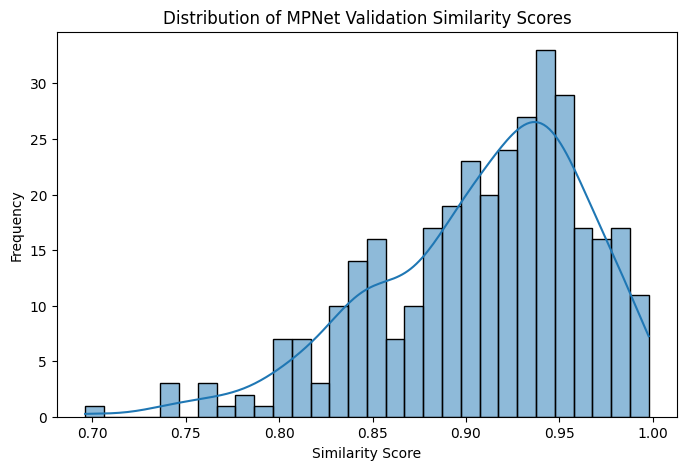

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(mpnet_results_df["similarity_score"], bins=30, kde=True)
plt.title("Distribution of MPNet Validation Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

Save Phase 4 validation results

In [17]:
mpnet_results_df.to_csv("validation_results_mpnet.csv", index=False)
best_mpnet_cases.to_csv("validation_best_cases_mpnet.csv", index=False)
worst_mpnet_cases.to_csv("validation_worst_cases_mpnet.csv", index=False)
comparison_mpnet_df.to_csv("comparison_minilm_vs_mpnet.csv", index=False)

print("Saved Phase 4 validation evaluation files.")

Saved Phase 4 validation evaluation files.


## Testing

Load the test set

In [18]:
test_df = pd.read_csv("test.csv")

print("Test shape:", test_df.shape)
test_df.head()

Test shape: (338, 2)


,Question,Answer
0,How can individuals benefit from increasing th...,Vitamin K supports proper blood clotting and b...
1,How do blood drive hosts engage with religious...,Blood drive hosts collaborate with religious a...
2,What measures can be implemented to ensure the...,Measures may include developing ethical guidel...
3,What role do donor advocacy groups and organiz...,Donor advocacy groups and organizations can su...
4,What factors contribute to the usage intention...,Factors contributing to the usage intentions o...


Prepare test questions and answers

In [19]:
test_questions = test_df["Question"].tolist()
test_answers = test_df["Answer"].tolist()

print("Number of test questions:", len(test_questions))

Number of test questions: 338


Run MPNet retrieval on all test questions

In [20]:
mpnet_test_results = []

for true_question, true_answer in zip(test_questions, test_answers):
    output = retrieve_answer_mpnet(
        true_question,
        train_questions,
        train_answers,
        mpnet_question_embeddings,
        mpnet_model
    )
    
    mpnet_test_results.append({
        "test_question": true_question,
        "expected_answer": true_answer,
        "matched_question": output["matched_question"],
        "retrieved_answer": output["retrieved_answer"],
        "similarity_score": output["similarity_score"]
    })

mpnet_test_results_df = pd.DataFrame(mpnet_test_results)

print("MPNet test retrieval completed.")
mpnet_test_results_df.head()

MPNet test retrieval completed.


,test_question,expected_answer,matched_question,retrieved_answer,similarity_score
0,How can individuals benefit from increasing th...,Vitamin K supports proper blood clotting and b...,How can individuals benefit from increasing th...,Increasing vitamin C intake supports iron abso...,0.874593
1,How do blood drive hosts engage with religious...,Blood drive hosts collaborate with religious a...,How do blood donation centers engage with reli...,Blood donation centers engage with religious i...,0.885446
2,What measures can be implemented to ensure the...,Measures may include developing ethical guidel...,What measures can be implemented to ensure the...,Measures may include stringent donor screening...,0.844169
3,What role do donor advocacy groups and organiz...,Donor advocacy groups and organizations can su...,What role does donor advocacy play in prioriti...,Donor advocacy plays a crucial role in priorit...,0.927802
4,What factors contribute to the usage intention...,Factors contributing to the usage intentions o...,How do perceptions of donation convenience and...,Perceptions of donation convenience and access...,0.762410


Similarity score summary

In [21]:
print("MPNet Test Similarity Score Summary:")
print(mpnet_test_results_df["similarity_score"].describe())

MPNet Test Similarity Score Summary:
count    338.000000
mean       0.905812
std        0.053732
min        0.718825
25%        0.875447
50%        0.913307
75%        0.944881
max        0.998069
Name: similarity_score, dtype: float64


Compute MPNet test semantic accuracy

In [22]:
mpnet_test_accuracy_085 = (mpnet_test_results_df["similarity_score"] >= 0.85).mean() * 100
mpnet_test_accuracy_090 = (mpnet_test_results_df["similarity_score"] >= 0.90).mean() * 100

print("MPNet Test Semantic Retrieval Accuracy (>= 0.85):", round(mpnet_test_accuracy_085, 2), "%")
print("MPNet Test Strict Semantic Retrieval Accuracy (>= 0.90):", round(mpnet_test_accuracy_090, 2), "%")

MPNet Test Semantic Retrieval Accuracy (>= 0.85): 85.5 %
MPNet Test Strict Semantic Retrieval Accuracy (>= 0.90): 59.47 %


Compare MPNet test performance with MiniLM test performance

In [23]:
comparison_mpnet_test_df = pd.DataFrame({
    "Metric": [
        "Semantic Accuracy >= 0.85",
        "Strict Semantic Accuracy >= 0.90"
    ],
    "MiniLM Test": [
        80.77,   # replace if your actual MiniLM test result was different
        54.44    # replace if your actual MiniLM test result was different
    ],
    "MPNet Test": [
        round(mpnet_test_accuracy_085, 2),
        round(mpnet_test_accuracy_090, 2)
    ]
})

comparison_mpnet_test_df["Improvement"] = comparison_mpnet_test_df["MPNet Test"] - comparison_mpnet_test_df["MiniLM Test"]
comparison_mpnet_test_df

,Metric,MiniLM Test,MPNet Test,Improvement
0,Semantic Accuracy >= 0.85,80.77,85.50,4.73
1,Strict Semantic Accuracy >= 0.90,54.44,59.47,5.03


View best MPNet test cases

In [24]:
best_mpnet_test_cases = mpnet_test_results_df.sort_values("similarity_score", ascending=False).head(10)

best_mpnet_test_cases[[
    "test_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,test_question,matched_question,retrieved_answer,similarity_score
85,How can public health campaigns effectively in...,How can public health campaigns integrate bloo...,Public health campaigns can effectively integr...,0.998069
312,What strategies can blood donation centers use...,What strategies can blood donation centers emp...,Blood donation centers can employ strategies s...,0.993682
78,How might whole blood donation impact producti...,How might whole blood donation impact producti...,Whole blood donation may temporarily decrease ...,0.991513
40,What impact do donor recognition programs or r...,How do donor recognition programs or rewards a...,Donor recognition programs or rewards can posi...,0.991440
129,How do blood donation centers ensure the confi...,How do blood donation centers ensure the confi...,Blood donation centers ensure the confidential...,0.991181
56,How might blood donation impact individuals' c...,How might blood donation impact cognitive func...,Blood donation can temporarily impact cognitiv...,0.991037
13,What strategies can health organizations use t...,What methods can health organizations use to i...,Health organizations can increase participatio...,0.990566
177,What strategies can blood donation centers use...,What strategies can blood donation centers use...,Blood donation centers can use strategies to e...,0.990163
122,What measures can blood donation centers take ...,What measures can blood donation organizations...,Blood donation organizations can work with hea...,0.987544
165,How do perceptions of stigma or discrimination...,How do perceptions of donation stigma or discr...,Perceptions of donation stigma or discriminati...,0.986638


View weakest MPNet test cases

In [25]:
worst_mpnet_test_cases = mpnet_test_results_df.sort_values("similarity_score", ascending=True).head(20)

worst_mpnet_test_cases[[
    "test_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,test_question,matched_question,retrieved_answer,similarity_score
145,What role does ABC play in ensuring a steady s...,How does ABC benefit blood banks?,ABC benefits blood banks by allowing them to c...,0.718825
39,How can individuals benefit from consuming mor...,How can individuals benefit from increasing th...,"Legumes provide plant-based protein, fiber, an...",0.720750
142,In what ways can blood donation affect individ...,How can blood donation impact individuals with...,Blood donation might assist those with chronic...,0.726848
337,How can individuals benefit from consuming mor...,How can individuals benefit from consuming fun...,"Functional foods such as probiotics, prebiotic...",0.749361
4,What factors contribute to the usage intention...,How do perceptions of donation convenience and...,Perceptions of donation convenience and access...,0.762410
203,Can you explain the concept of apheresis donat...,How might apheresis impact the frequency of do...,Apheresis may allow donors to donate specific ...,0.765128
249,What is the significance of maintaining approp...,What is the focus of bottom-up planning proces...,Bottom-up plans focus on establishing potentia...,0.768336
48,What role does donor retention play in maintai...,What are the potential consequences of relying...,Relying on repeat donors versus recruiting new...,0.770257
267,"How do workplace policies, such as paid time o...",What impact do employer-sponsored donation pro...,"Employer-sponsored donation programs, such as ...",0.771562
209,How can individuals benefit from consuming foo...,How can individuals benefit from increasing th...,Iron-fortified foods help maintain healthy iro...,0.776415


Visualize MPNet test similarity distribution

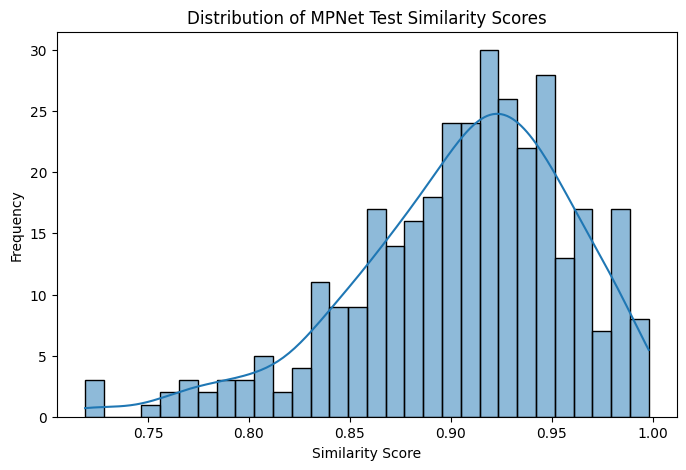

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(mpnet_test_results_df["similarity_score"], bins=30, kde=True)
plt.title("Distribution of MPNet Test Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

Add confidence labels

In [27]:
def confidence_label(score):
    if score >= 0.90:
        return "Very High"
    elif score >= 0.85:
        return "High"
    elif score >= 0.75:
        return "Moderate"
    else:
        return "Low"

mpnet_test_results_df["confidence_level"] = mpnet_test_results_df["similarity_score"].apply(confidence_label)

print(mpnet_test_results_df["confidence_level"].value_counts())

confidence_level
Very High    201
High          88
Moderate      45
Low            4
Name: count, dtype: int64


Save MPNet test results

In [28]:
mpnet_test_results_df.to_csv("test_results_mpnet.csv", index=False)
best_mpnet_test_cases.to_csv("test_best_cases_mpnet.csv", index=False)
worst_mpnet_test_cases.to_csv("test_worst_cases_mpnet.csv", index=False)
comparison_mpnet_test_df.to_csv("comparison_minilm_vs_mpnet_test.csv", index=False)

print("Saved MPNet test evaluation files.")

Saved MPNet test evaluation files.


Final summary table

In [29]:
mpnet_final_summary = {
    "Test samples": len(mpnet_test_results_df),
    "Semantic Retrieval Accuracy (>= 0.85)": round(mpnet_test_accuracy_085, 2),
    "Strict Semantic Retrieval Accuracy (>= 0.90)": round(mpnet_test_accuracy_090, 2),
    "Average similarity score": round(mpnet_test_results_df["similarity_score"].mean(), 4),
    "Minimum similarity score": round(mpnet_test_results_df["similarity_score"].min(), 4),
    "Maximum similarity score": round(mpnet_test_results_df["similarity_score"].max(), 4)
}

mpnet_final_summary_df = pd.DataFrame(list(mpnet_final_summary.items()), columns=["Metric", "Value"])
mpnet_final_summary_df

,Metric,Value
0,Test samples,338.0000
1,Semantic Retrieval Accuracy (>= 0.85),85.5000
2,Strict Semantic Retrieval Accuracy (>= 0.90),59.4700
3,Average similarity score,0.9058
4,Minimum similarity score,0.7188
5,Maximum similarity score,0.9981


Compare MPNet validation and test performance

In [30]:
comparison_mpnet_generalization_df = pd.DataFrame({
    "Metric": [
        "Semantic Accuracy >= 0.85",
        "Strict Semantic Accuracy >= 0.90"
    ],
    "Validation (MPNet)": [
        83.73,
        62.72
    ],
    "Test (MPNet)": [
        round(mpnet_test_accuracy_085, 2),
        round(mpnet_test_accuracy_090, 2)
    ]
})

comparison_mpnet_generalization_df["Difference"] = comparison_mpnet_generalization_df["Test (MPNet)"] - comparison_mpnet_generalization_df["Validation (MPNet)"]
comparison_mpnet_generalization_df

,Metric,Validation (MPNet),Test (MPNet),Difference
0,Semantic Accuracy >= 0.85,83.73,85.50,1.77
1,Strict Semantic Accuracy >= 0.90,62.72,59.47,-3.25
